# 04 — Análisis de Nulos y Outliers

**Posición en el pipeline**: entre EDA (`03_eda.ipynb`) y Preprocessing (`05_preprocessing.ipynb`).

## ¿Por qué este notebook?

El preprocessing ciego (imputar todo con la mediana, clipear al p99) introduce decisiones
implícitas que pueden sesgar el modelo. Este notebook las hace **explícitas**: antes de aplicar
cualquier transformación, catalogamos todos los nulos y valores extremos, identificamos su
causa probable y decidimos el tratamiento más adecuado para cada uno.

## Tipos de nulos que encontramos

| Tipo | Significado | Tratamiento habitual |
|------|------------|---------------------|
| **Estructural** | El dato no puede existir (p.ej. nota de Matemáticas para un alumno de Infantil sin esa asignatura) | Imputar 0 o mediana del grupo; crear indicador binario de ausencia |
| **MCAR** (Missing Completely At Random) | Falta al azar, sin relación con el valor real ni otras variables | Imputar con mediana global; eliminar filas si hay pocas |
| **MAR** (Missing At Random) | La falta depende de otras variables observadas (p.ej. faltan notas de 2EV porque la asignatura no tiene 2EV) | Imputar con mediana de grupo condicionada; considerar modelo de imputación |
| **MNAR** (Missing Not At Random) | La falta depende del valor mismo (p.ej. alumnos que abandonaron no tienen nota final) | Documentar como limitación; crear indicador de ausencia; analizar sesgo |

## Tipos de outliers

| Tipo | Detectar con | Tratamiento habitual |
|------|-------------|---------------------|
| **Error de datos** | Valor imposible (nota > 10, edad < 0) | Corregir o eliminar la fila |
| **Valor extremo real** | z-score > 3 o fuera de [Q1-3·IQR, Q3+3·IQR] | Winsorizar al percentil 99; log-transform; mantener si el modelo es robusto |
| **Grupo pequeño** | Una categoría tiene muy pocas observaciones | Agrupar con 'otros'; eliminar si es ruido |

**Output de este notebook**: tabla de decisiones para el notebook 05 (preprocessing).

In [1]:
# ── Imports y configuración ───────────────────────────────────────────────────
# Usamos scipy.stats para z-scores, y matplotlib/seaborn para visualizaciones.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Detectar raíz del proyecto desde cualquier subcarpeta
_cwd = Path('.').resolve()
BASE_DIR = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent] if (p / 'data').exists()),
    _cwd.parent
)

# Cargamos el dataset enriquecido (después de NB01 + NB02): contiene features base,
# competenciales y notas diarias. Es el punto más completo antes de preprocessing.
P_IN = BASE_DIR / 'data' / 'dataset_v11.csv'
assert P_IN.exists(), f'No encontrado: {P_IN} — ejecuta primero 01 y 02'

df = pd.read_csv(P_IN)
CAT_ORDER = ['buen_alumno', 'en_riesgo', 'con_dificultades']

print(f'Dataset cargado: {df.shape[0]} observaciones × {df.shape[1]} columnas')
print(f'\nDistribución del target:')
print(df['categoria_target'].value_counts())
# edad_relativa SOLO para EDA descriptiva (en el modelo se centra dentro del pipeline,
# por fold, sin leakage). Aqui es exploracion, asi que se recompone globalmente.
if 'edad_inicio' in df.columns and 'edad_relativa' not in df.columns:
    df['edad_relativa'] = df['edad_inicio'] - df.groupby(['NivCurso','Ejercicio'])['edad_inicio'].transform('mean')


Dataset cargado: 1205 observaciones × 59 columnas

Distribución del target:
categoria_target
buen_alumno         867
en_riesgo           213
con_dificultades    125
Name: count, dtype: int64


## 1. Resumen global de nulos

Antes de tratar cada feature individualmente, queremos una vista de conjunto:
¿cuántas columnas tienen nulos? ¿cuántas filas tienen al menos un nulo?
¿los nulos se concentran en unas pocas features o están dispersos?

In [2]:
# ── Tabla global de nulos ─────────────────────────────────────────────────────
# Para cada columna: contamos nulos, calculamos porcentaje, identificamos el tipo
# de dato (numérico/categórico) y clasificamos el grupo de feature.
null_counts = df.isna().sum()
null_pct    = (null_counts / len(df) * 100).round(1)

def clasificar_grupo(col):
    """Clasifica cada feature en un grupo temático para facilitar el análisis."""
    if col in ('GuidAlumno', 'Ejercicio', 'IdCentro', 'categoria_target', 'target_num'):
        return 'Identificadores/Target'
    if col in ('suspensos', 'aprobadas', 'nota_media_final', 'total_asignaturas',
               'origen_nota_final', 'numero_eval_max'):
        return 'Leakage (excluir)'
    if col.startswith('nota_') and not col.startswith('nota_diaria'):
        return 'Notas base 1EV'
    if col.startswith('n_') or col in ('pct_aprobado_1ev',):
        return 'Conteos 1EV'
    if col in ('NivEstudio', 'NivCurso', 'IsRepetidor', 'Sexo',
               'mes_nacimiento', 'trimestre_nacimiento', 'edad_relativa',
               'IdNEE', 'HermanosPosicion'):
        return 'Demografía'
    if col.startswith(('total_incidencias', 'no_justificadas', 'justificadas')):
        return 'Asistencia'
    if '__' in col:
        return 'Competencias'
    if col.startswith('nota_diaria') or col.startswith('n_act') or col.startswith('pct_act'):
        return 'Notas diarias (solo 2020)'
    return 'Otro'

resumen = pd.DataFrame({
    'n_nulos': null_counts,
    'pct_nulos': null_pct,
    'dtype': df.dtypes,
    'grupo': pd.Series({c: clasificar_grupo(c) for c in df.columns})
})
resumen = resumen[resumen['n_nulos'] > 0].sort_values('pct_nulos', ascending=False)

print(f'Columnas con al menos un nulo: {len(resumen)} de {len(df.columns)}')
print(f'Filas con al menos un nulo   : {df.isna().any(axis=1).sum()} de {len(df)}')
print(f'\nNulos por grupo temático:')
print(resumen.groupby('grupo')['n_nulos'].sum().sort_values(ascending=False).to_string())
print()
print('Detalle por feature:')
resumen

Columnas con al menos un nulo: 31 de 60
Filas con al menos un nulo   : 1182 de 1205

Nulos por grupo temático:
grupo
Competencias      6421
Notas base 1EV    3378

Detalle por feature:


,n_nulos,pct_nulos,dtype,grupo
mat__Religion_Valores,1106,91.800,float64,Competencias
mat__Tecnologia,931,77.300,float64,Competencias
pct_asignaturas__PERS,898,74.500,float64,Competencias
nota_max__PERS,898,74.500,float64,Notas base 1EV
nota_media__PERS,898,74.500,float64,Notas base 1EV
nota_min__PERS,898,74.500,float64,Notas base 1EV
pct_aprobado__PERS,898,74.500,float64,Competencias
mat__Sociales,759,63.000,float64,Competencias
mat__Lengua_Extranjera,317,26.300,float64,Competencias
mat__Educacion_Artistica,305,25.300,float64,Competencias


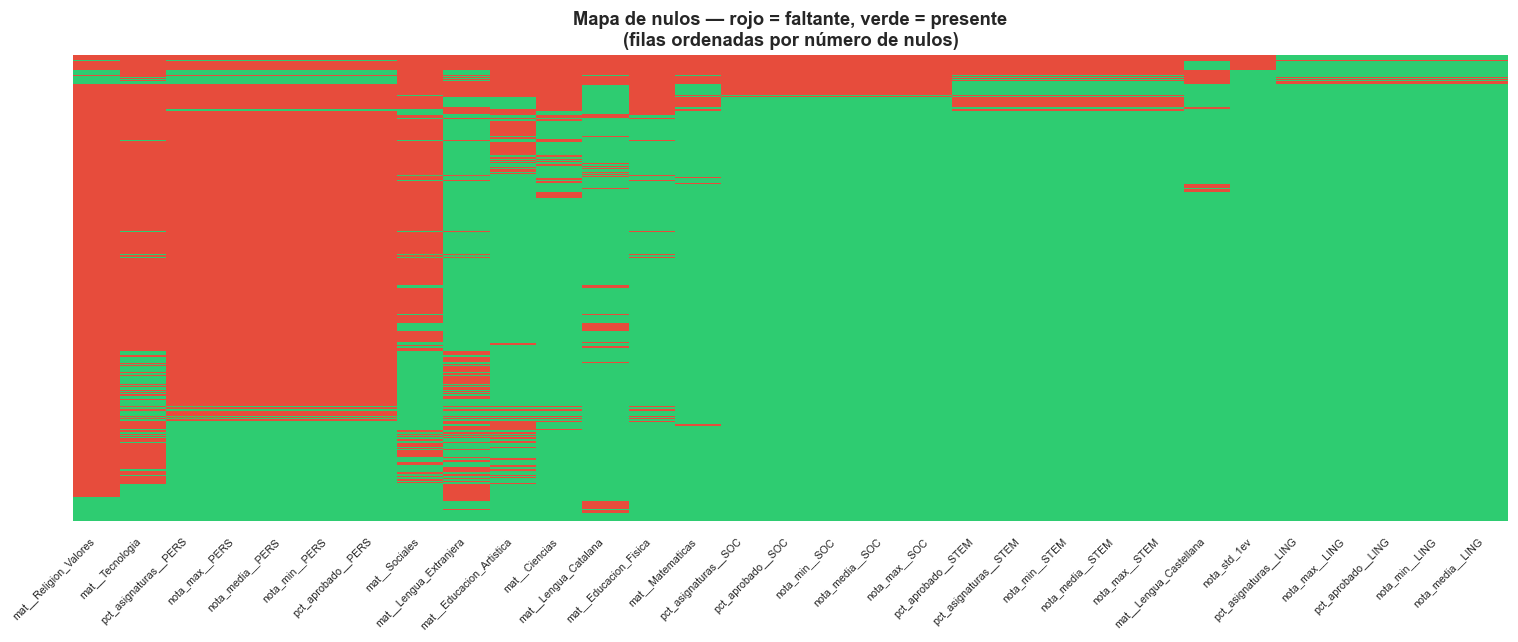

Observación: los nulos en columnas competenciales y demográficas forman bloques
horizontales → son los mismos alumnos los que tienen nulos en múltiples features.
Esto es coherente con nulos estructurales (alumnos sin datos de esa evaluación).


In [3]:
# ── Mapa de calor de nulos ────────────────────────────────────────────────────
# Muestra el patrón espacial de los nulos: si los nulos de una columna coinciden
# con los de otra, probablemente tienen la misma causa (mismo alumno sin datos).
# Observamos si los nulos se concentran en bloques de filas → indicio de MAR.

cols_con_nulos = resumen.index.tolist()
# Limitamos a las features que son realmente features del modelo (excluimos leakage)
cols_plot = [c for c in cols_con_nulos
             if clasificar_grupo(c) not in ('Identificadores/Target', 'Leakage (excluir)', 'Otro')]

fig, ax = plt.subplots(figsize=(14, 6))
# Ordenar filas por número de nulos para ver el patrón
idx_ordered = df[cols_plot].isna().sum(axis=1).sort_values(ascending=False).index
sns.heatmap(
    df.loc[idx_ordered, cols_plot].isna(),
    yticklabels=False, cbar=False,
    cmap=['#2ecc71', '#e74c3c'],  # verde=dato presente, rojo=nulo
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_title('Mapa de nulos — rojo = faltante, verde = presente\n(filas ordenadas por número de nulos)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('Observación: los nulos en columnas competenciales y demográficas forman bloques')
print('horizontales → son los mismos alumnos los que tienen nulos en múltiples features.')
print('Esto es coherente con nulos estructurales (alumnos sin datos de esa evaluación).')

## 2. Análisis de nulos por grupo de features

Cada grupo de features tiene una causa diferente para sus nulos. La distinción importa porque
el tratamiento correcto depende de **por qué** falta el dato, no solo de cuántos faltan.

In [4]:
# ── 2a. Notas base de 1EV ─────────────────────────────────────────────────────
# Los nulos en nota_media_1ev, nota_min_1ev, etc. ocurren cuando un alumno no tiene
# NINGUNA nota numérica en Q01 (primera evaluación). Esto puede pasar si:
#   - El alumno está en Infantil y las notas se expresan como texto (A/B/C, no número)
#   - El registro del alumno existe en el target pero no en las notas
# Tipo de nulo: ESTRUCTURAL (el alumno existe pero no tiene notas numéricas)
# Tratamiento en NB05: imputar 0 + crear indicador sin_notas_1ev=1

notas_base = ['nota_media_1ev', 'nota_min_1ev', 'nota_max_1ev', 'nota_std_1ev',
              'n_asignaturas_1ev', 'n_aprobadas_1ev', 'n_suspensos_1ev', 'pct_aprobado_1ev']
notas_base = [c for c in notas_base if c in df.columns]

print('=== Notas base de 1EV ===')
print(f'Tipo de nulo: ESTRUCTURAL — alumno existe en el sistema pero sin notas numéricas en 1EV')
print(f'Causa probable: Infantil (notas cualitativas) o alumno sin datos en Q01')
print(f'Tratamiento: imputar 0 + indicador sin_notas_1ev (ya aplicado en NB05)\n')
for c in notas_base:
    n = df[c].isna().sum()
    pct = n / len(df) * 100
    print(f'  {c:<25}: {n:>3} nulos ({pct:.1f}%)')

# ¿Qué niveles son los que tienen esos nulos?
print(f'\nNiveles con nota_media_1ev nula:')
if 'nota_media_1ev' in df.columns and 'NivEstudio' in df.columns:
    print(df[df['nota_media_1ev'].isna()]['NivEstudio'].value_counts().to_string())

=== Notas base de 1EV ===
Tipo de nulo: ESTRUCTURAL — alumno existe en el sistema pero sin notas numéricas en 1EV
Causa probable: Infantil (notas cualitativas) o alumno sin datos en Q01
Tratamiento: imputar 0 + indicador sin_notas_1ev (ya aplicado en NB05)

  nota_media_1ev           :   0 nulos (0.0%)
  nota_min_1ev             :   0 nulos (0.0%)
  nota_max_1ev             :   0 nulos (0.0%)
  nota_std_1ev             :  39 nulos (3.2%)
  n_asignaturas_1ev        :   0 nulos (0.0%)
  n_aprobadas_1ev          :   0 nulos (0.0%)
  n_suspensos_1ev          :   0 nulos (0.0%)
  pct_aprobado_1ev         :   0 nulos (0.0%)

Niveles con nota_media_1ev nula:
Series([], )


In [5]:
# ── 2b. Demografía ────────────────────────────────────────────────────────────
# Los nulos demográficos (Sexo, edad_relativa, IdNEE, etc.) ocurren en alumnos
# cuyo target viene de la 2ª evaluación (E_2ev) y no tienen ficha completa.
# Tipo de nulo: MAR (Missing At Random) — la falta depende de 'origen_nota_final'
# que es observable.
# Tratamiento: imputar mediana por grupo educativo (NivCurso × Ejercicio).
# El modelo luego puede aprender sin NA en estas variables.

demo_cols = ['Sexo', 'mes_nacimiento', 'trimestre_nacimiento', 'edad_relativa',
             'IdNEE', 'HermanosPosicion', 'IsRepetidor']
demo_cols = [c for c in demo_cols if c in df.columns]

print('=== Demografía ===')
print('Tipo de nulo: MAR — correlacionado con origen_nota_final (alumnos sin 2EV o sin ficha)')
print('Causa: alumnos cuya evaluación final viene de 2EV no tienen datos demográficos completos')
print('Tratamiento: mediana por grupo (NivEstudio × Ejercicio) en el pipeline del NB05\n')

for c in demo_cols:
    n = df[c].isna().sum()
    pct = n / len(df) * 100
    print(f'  {c:<25}: {n:>3} nulos ({pct:.1f}%)')

# Verificar la correlación entre nulos y origen
if '_origen_nota_final' in df.columns or 'origen_nota_final' in df.columns:
    col_origen = '_origen_nota_final' if '_origen_nota_final' in df.columns else 'origen_nota_final'
    print(f'\nNulos en Sexo por origen del target:')
    print(df.groupby(col_origen)['Sexo'].apply(lambda x: x.isna().sum()).to_string())

=== Demografía ===
Tipo de nulo: MAR — correlacionado con origen_nota_final (alumnos sin 2EV o sin ficha)
Causa: alumnos cuya evaluación final viene de 2EV no tienen datos demográficos completos
Tratamiento: mediana por grupo (NivEstudio × Ejercicio) en el pipeline del NB05

  Sexo                     :   0 nulos (0.0%)
  mes_nacimiento           :   0 nulos (0.0%)
  trimestre_nacimiento     :   0 nulos (0.0%)
  edad_relativa            :   0 nulos (0.0%)
  IdNEE                    :   0 nulos (0.0%)
  HermanosPosicion         :   0 nulos (0.0%)
  IsRepetidor              :   0 nulos (0.0%)


In [6]:
# ── 2c. Features competenciales ───────────────────────────────────────────────
# Las features como nota_media__STEM, pct_aprobado__LING, etc. son NaN cuando
# el alumno no tiene NINGUNA asignatura en ese bloque competencial.
# Ejemplo: un alumno de Infantil no tiene materias STEM → nota_media__STEM = NaN.
# Tipo de nulo: ESTRUCTURAL — la ausencia de dato es información real.
# "No tiene Matemáticas" no es lo mismo que "tiene una nota media de 0 en Matemáticas".
# Tratamiento:
#   - Para variables de nota (nota_media, nota_min, etc.): imputar mediana del grupo
#   - Crear indicadores binarios tiene_dato__BLOQUE=0/1 (ya generados en NB05)

comp_cols = [c for c in df.columns if '__' in c]
print('=== Features competenciales ===')
print('Tipo de nulo: ESTRUCTURAL — el alumno no tiene asignaturas de esa competencia')
print('Los indicadores tiene_dato__X codifican esta ausencia como feature explícita')
print('Tratamiento: imputar mediana por nivel educativo (GroupMedianImputer en NB05)\n')

comp_df = pd.DataFrame({
    'feature': comp_cols,
    'n_nulos': [df[c].isna().sum() for c in comp_cols],
    'pct_nulos': [(df[c].isna().sum() / len(df) * 100) for c in comp_cols],
    'bloque': [c.split('__')[1] if '__' in c else '?' for c in comp_cols],
    'metrica': [c.split('__')[0] if '__' in c else '?' for c in comp_cols],
}).sort_values('pct_nulos', ascending=False)
print(comp_df.to_string(index=False))

=== Features competenciales ===
Tipo de nulo: ESTRUCTURAL — el alumno no tiene asignaturas de esa competencia
Los indicadores tiene_dato__X codifican esta ausencia como feature explícita
Tratamiento: imputar mediana por nivel educativo (GroupMedianImputer en NB05)

                 feature  n_nulos  pct_nulos              bloque         metrica
   mat__Religion_Valores     1106     91.784    Religion_Valores             mat
         mat__Tecnologia      931     77.261          Tecnologia             mat
      pct_aprobado__PERS      898     74.523                PERS    pct_aprobado
   pct_asignaturas__PERS      898     74.523                PERS pct_asignaturas
          nota_max__PERS      898     74.523                PERS        nota_max
          nota_min__PERS      898     74.523                PERS        nota_min
        nota_media__PERS      898     74.523                PERS      nota_media
           mat__Sociales      759     62.988            Sociales             mat
  mat

In [7]:
# ── 2d. Notas diarias (solo 2020) ─────────────────────────────────────────────
# Las variables nota_diaria_*, n_act_*, pct_act_* son NaN para TODOS los alumnos
# que no son del año 2020. En 2020 se usó EvaNotaDiariaNota (registro de actividades
# de aula); en otros años ese sistema no se activó.
# Tipo de nulo: MAR por año — completamente dependiente de Ejercicio=2020.
# Tratamiento:
#   - Mantener NaN para alumnos fuera de 2020 (NaN como señal)
#   - Los conteos (n_act_*) → 0 para no-2020 (sin actividades = 0)
#   - Las notas (nota_diaria_*) → NaN, imputar mediana global en pipeline
#   - Crear indicador tiene_nota_diaria=1/0 (ya generado en NB05)

nd_cols = [c for c in df.columns
           if c.startswith(('nota_diaria', 'n_act', 'n_asig_con_act', 'pct_act'))]
print('=== Notas diarias (solo año 2020) ===')
print('Tipo de nulo: MAR por año — depende de Ejercicio=2020')
print('El indicador tiene_nota_diaria=1/0 codifica si el alumno tiene este tipo de datos')
print('Tratamiento: n_act_* → 0 para no-2020; nota_diaria_* → mediana global en pipeline\n')

for c in nd_cols:
    n = df[c].isna().sum()
    pct = n / len(df) * 100
    print(f'  {c:<35}: {n:>3} nulos ({pct:.1f}%)')

if 'Ejercicio' in df.columns and nd_cols:
    print(f'\nVerificación — nulos en nota_diaria_media_1ev por año:')
    c = nd_cols[0] if nd_cols else None
    if c:
        print(df.groupby('Ejercicio')[c].apply(lambda x: f'{x.isna().sum()}/{len(x)} nulos').to_string())

=== Notas diarias (solo año 2020) ===
Tipo de nulo: MAR por año — depende de Ejercicio=2020
El indicador tiene_nota_diaria=1/0 codifica si el alumno tiene este tipo de datos
Tratamiento: n_act_* → 0 para no-2020; nota_diaria_* → mediana global en pipeline



## 3. Análisis de outliers

Usamos dos métodos complementarios:
- **IQR** (Interquartile Range): marca como outlier cualquier valor fuera de [Q1 - k·IQR, Q3 + k·IQR].
  Con k=1.5 es el criterio estándar; k=3 detecta solo los más extremos.
- **z-score**: marca como outlier cualquier valor a más de 3 desviaciones estándar de la media.
  Más sensible a distribuciones simétricas; menos robusto con distribuciones sesgadas.

Para este dataset, **el IQR con k=3 es más apropiado** porque muchas distribuciones son asimétricas
(pocas faltas, notas concentradas en rangos específicos por nivel).

In [8]:
# ── Detección de outliers en features numéricas clave ─────────────────────────
# Solo analizamos las features que entran al modelo (excluimos target, leakage, IDs).
EXCLUIR_OUTLIER = {
    'GuidAlumno', 'Ejercicio', 'IdCentro', 'target_num',
    'categoria_target', 'origen_nota_final', '_origen_nota_final',
    'numero_eval_max', 'total_asignaturas', 'suspensos', 'aprobadas', 'nota_media_final',
}

num_cols = [
    c for c in df.select_dtypes(include='number').columns
    if c not in EXCLUIR_OUTLIER
]

K_IQR = 3.0  # criterio conservador: solo detecta outliers muy extremos
Z_UMBRAL = 3.0

outlier_summary = []
for col in num_cols:
    serie = df[col].dropna()
    if len(serie) < 10:
        continue
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - K_IQR * IQR, Q3 + K_IQR * IQR
    n_iqr = ((serie < lb) | (serie > ub)).sum()

    zs = np.abs(stats.zscore(serie))
    n_z = (zs > Z_UMBRAL).sum()

    outlier_summary.append({
        'feature': col,
        'n_validos': len(serie),
        'media': round(serie.mean(), 3),
        'std': round(serie.std(), 3),
        'min': round(serie.min(), 3),
        'max': round(serie.max(), 3),
        'p1': round(serie.quantile(0.01), 3),
        'p99': round(serie.quantile(0.99), 3),
        'n_outliers_IQR': n_iqr,
        'pct_outliers_IQR': round(n_iqr / len(serie) * 100, 1),
        'n_outliers_z': n_z,
        'grupo': clasificar_grupo(col),
    })

out_df = pd.DataFrame(outlier_summary).sort_values('n_outliers_IQR', ascending=False)
con_outliers = out_df[out_df['n_outliers_IQR'] > 0]

print(f'Features con outliers IQR (k={K_IQR}): {len(con_outliers)} de {len(out_df)}')
print(f'Features sin outliers: {len(out_df) - len(con_outliers)}')
print()
con_outliers[['feature', 'n_validos', 'min', 'p1', 'p99', 'max',
               'n_outliers_IQR', 'pct_outliers_IQR', 'n_outliers_z', 'grupo']]

Features con outliers IQR (k=3.0): 22 de 50
Features sin outliers: 28



,feature,n_validos,min,p1,p99,max,n_outliers_IQR,pct_outliers_IQR,n_outliers_z,grupo
49,edad_relativa,1205,-30.333,-3.846,1.942,30.923,308,25.600,14,Demografía
34,pct_aprobado__STEM,1109,0.000,0.000,1.000,1.000,265,23.900,59,Competencias
17,no_justificadas_1ev,1205,0.000,0.000,1.000,3.500,206,17.100,6,Asistencia
33,pct_aprobado__SOC,1101,0.000,0.200,1.000,1.000,187,17.000,52,Competencias
18,justificadas_1ev,1205,0.000,0.000,5.000,9.000,156,12.900,40,Asistencia
15,HermanosPosicion,1205,0.000,0.000,3.000,4.000,78,6.500,58,Demografía
7,n_suspensos_1ev,1205,0.000,0.000,7.000,10.000,77,6.400,21,Conteos 1EV
32,pct_aprobado__PERS,307,0.000,0.000,1.000,1.000,56,18.200,0,Competencias
35,pct_asignaturas__LING,1190,0.154,0.200,1.000,1.000,38,3.200,38,Competencias
36,pct_asignaturas__PERS,307,0.083,0.083,0.500,1.000,36,11.700,1,Competencias


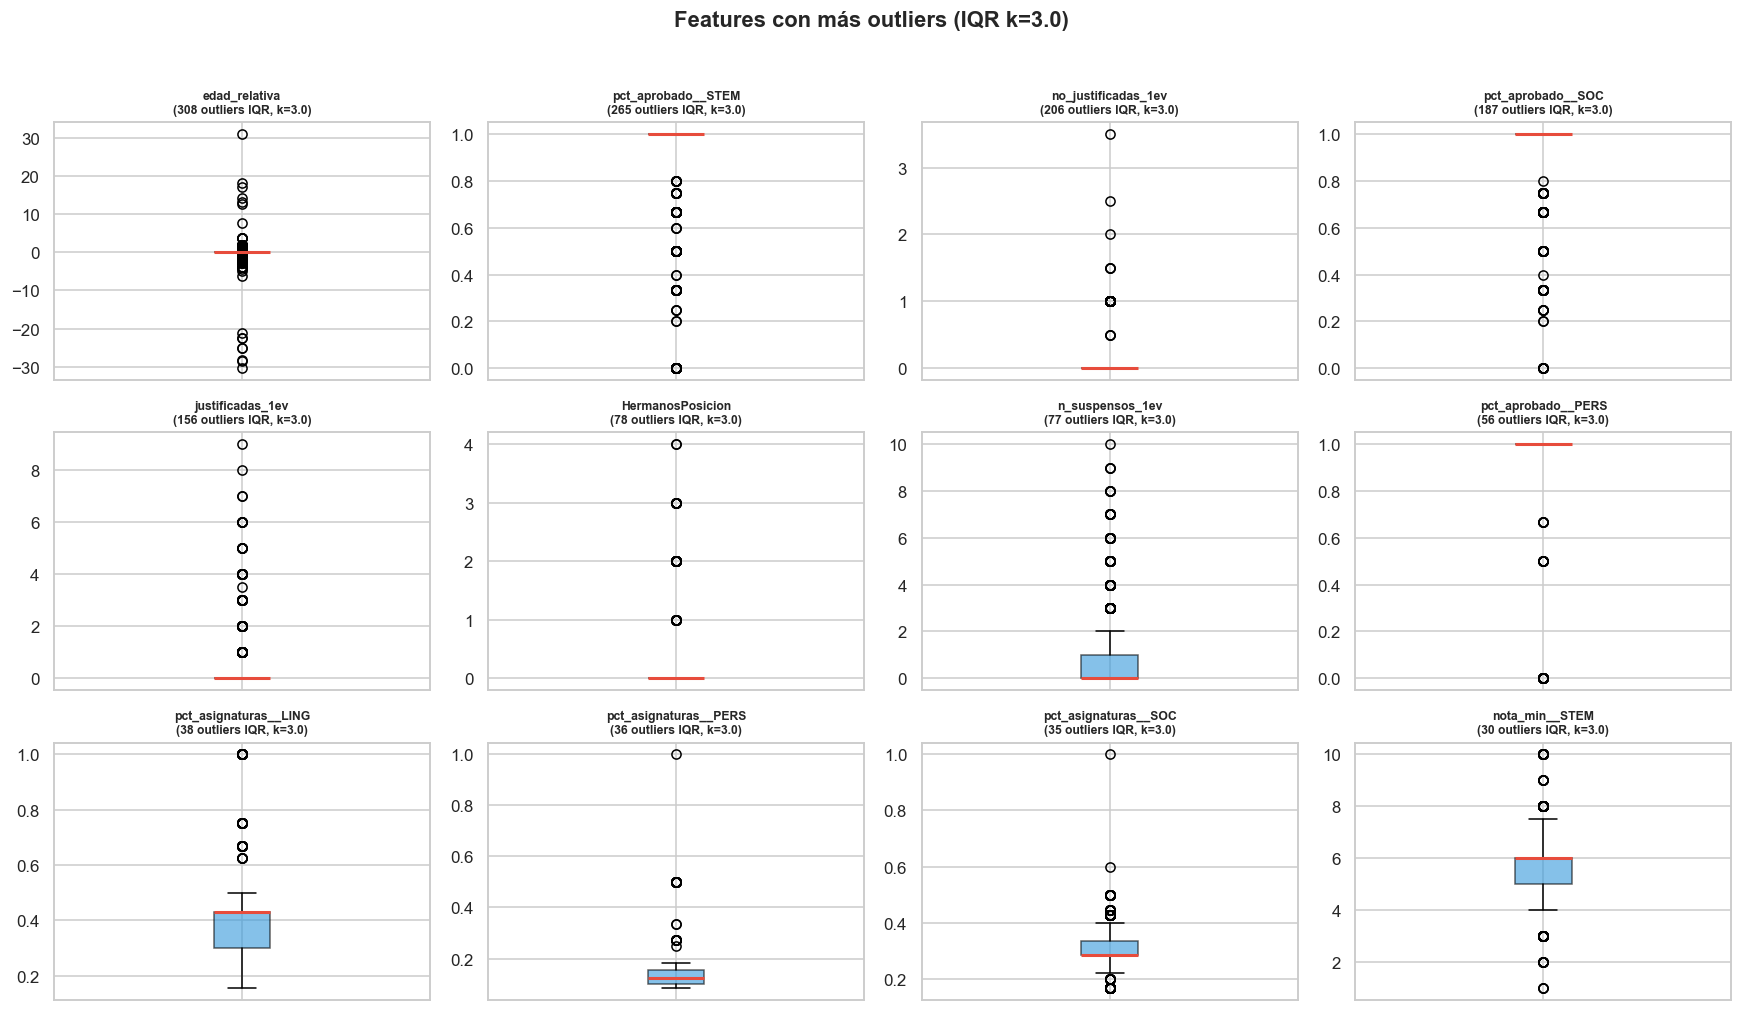

In [9]:
# ── Boxplots de las features con más outliers ─────────────────────────────────
# Visualizamos la distribución de las features con mayor número de outliers.
# Los boxplots permiten ver si los extremos son errores de datos o distribuciones
# genuinamente sesgadas (ej. muy pocos alumnos con muchas faltas).

top_outlier_cols = con_outliers.head(12)['feature'].tolist()
if top_outlier_cols:
    n_cols = min(4, len(top_outlier_cols))
    n_rows = (len(top_outlier_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, col in enumerate(top_outlier_cols):
        ax = axes[i]
        data = df[col].dropna()
        ax.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#3498db', alpha=0.6),
                   medianprops=dict(color='#e74c3c', linewidth=2))
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((data < Q1 - K_IQR*IQR) | (data > Q3 + K_IQR*IQR)).sum()
        ax.set_title(f'{col}\n({n_out} outliers IQR, k={K_IQR})', fontsize=8, fontweight='bold')
        ax.set_xticklabels([])

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Features con más outliers (IQR k={K_IQR})', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No hay features con outliers detectados.')

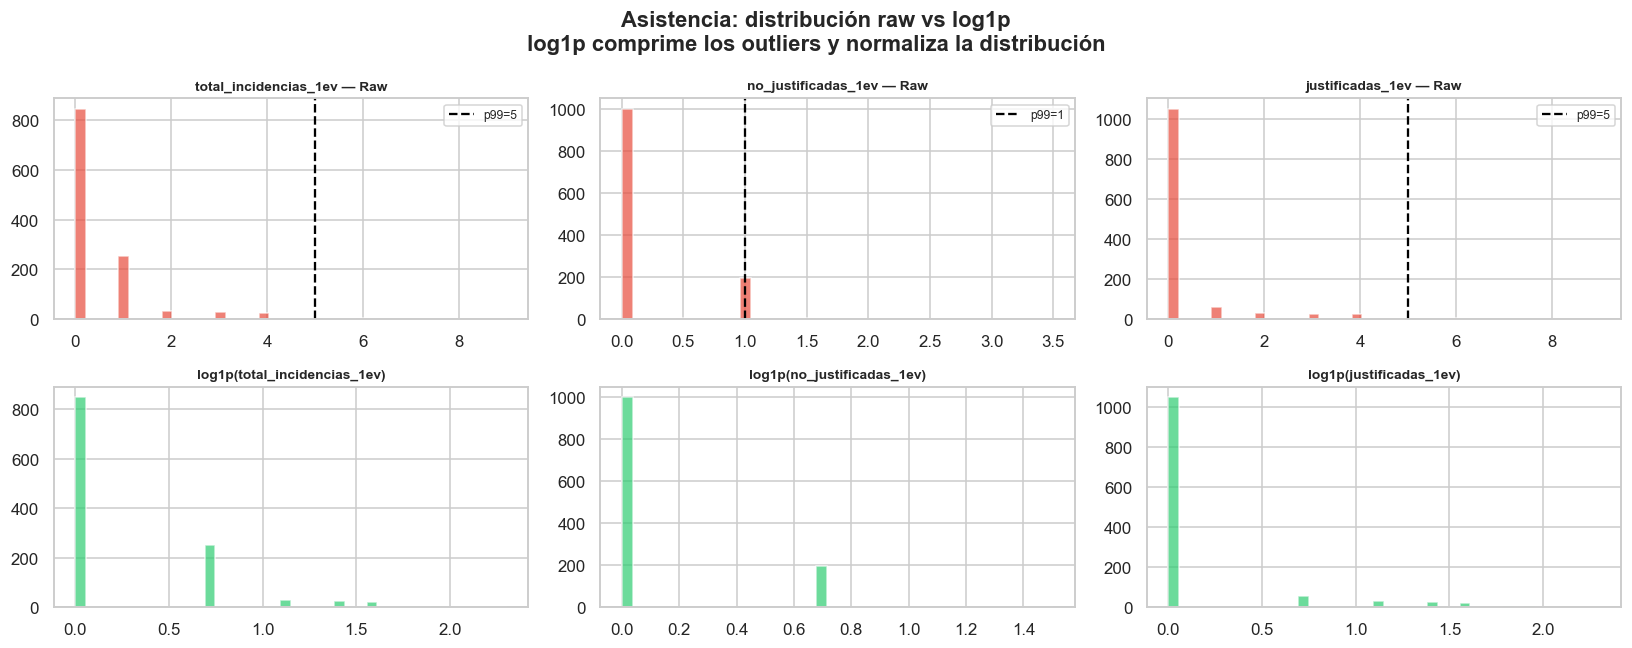

Conclusión: los valores extremos de faltas son reales (no errores de datos).
La transformación log1p los comprime sin eliminarlos.
Recomendación: aplicar log1p (ya implementado en NB05).


In [10]:
# ── Distribuciones de features de asistencia ──────────────────────────────────
# Las variables de faltas tienen distribuciones muy sesgadas a la derecha:
# la mayoría de alumnos tiene pocas faltas y unos pocos tienen muchas.
# Este sesgo justifica la transformación log1p que ya se aplica en NB05.
# Aquí verificamos visualmente que los outliers son reales (no errores).

asist_cols = [c for c in ['total_incidencias_1ev', 'no_justificadas_1ev', 'justificadas_1ev']
              if c in df.columns]

if asist_cols:
    fig, axes = plt.subplots(2, len(asist_cols), figsize=(5 * len(asist_cols), 6))
    if len(asist_cols) == 1:
        axes = [[axes[0]], [axes[1]]]

    for j, col in enumerate(asist_cols):
        data = df[col].dropna()
        # Raw
        axes[0][j].hist(data, bins=40, color='#e74c3c', alpha=0.7, edgecolor='white')
        p95, p99 = data.quantile(0.95), data.quantile(0.99)
        axes[0][j].axvline(p99, color='black', linestyle='--', label=f'p99={p99:.0f}')
        axes[0][j].set_title(f'{col} — Raw', fontsize=9, fontweight='bold')
        axes[0][j].legend(fontsize=8)
        # log1p
        axes[1][j].hist(np.log1p(data), bins=40, color='#2ecc71', alpha=0.7, edgecolor='white')
        axes[1][j].set_title(f'log1p({col})', fontsize=9, fontweight='bold')

    plt.suptitle('Asistencia: distribución raw vs log1p\nlog1p comprime los outliers y normaliza la distribución',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('Conclusión: los valores extremos de faltas son reales (no errores de datos).')
    print('La transformación log1p los comprime sin eliminarlos.')
    print('Recomendación: aplicar log1p (ya implementado en NB05).')

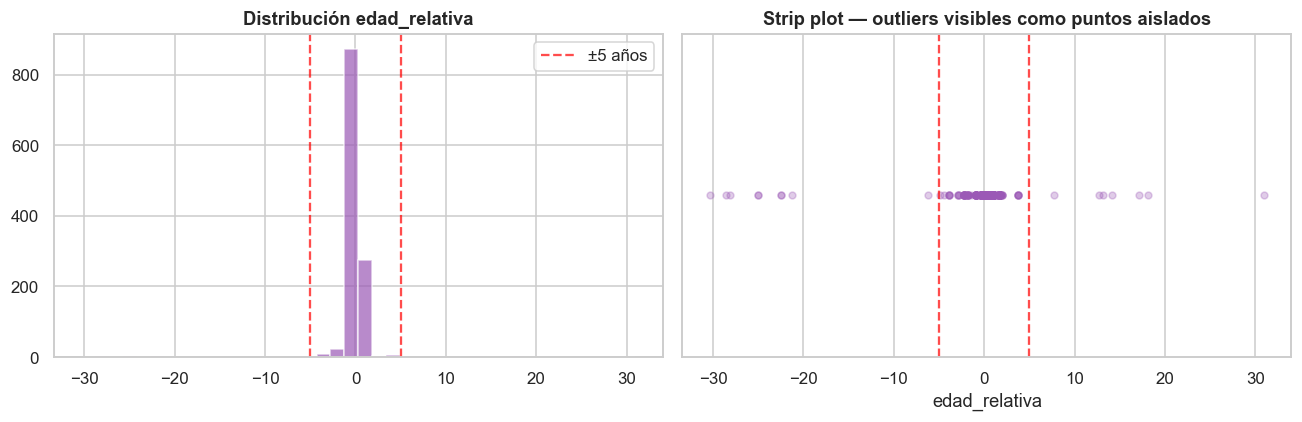

Alumnos con |edad_relativa| > 5 años: 16
De estos, con IdNEE > 0: 0

RECOMENDACIÓN: MANTENER tal cual
  → Los extremos son alumnos con necesidades especiales o historia educativa atípica.
  → Esta información es predictiva (correlación positiva con con_dificultades).
  → El escalado StandardScaler del NB05 normaliza el rango sin perder la información.


In [11]:
# ── Outliers en edad_relativa ─────────────────────────────────────────────────
# edad_relativa = diferencia de edad del alumno vs la media de su grupo (NivCurso × Ejercicio).
# Valores extremos (> ±5 años) pueden indicar:
#   - Alumnos con NEE que repiten varios años
#   - Alumnos que entran tarde al sistema educativo (migración reciente)
#   - Posibles errores de fecha de nacimiento
# Recomendación: NO clipear — el dato es real y la edad relativa grande es información
# importante (fuerte predictor de dificultades). Verificar si son alumnos con IdNEE > 0.

if 'edad_relativa' in df.columns:
    er = df['edad_relativa'].dropna()
    extremos = df[df['edad_relativa'].abs() > 5].copy() if 'edad_relativa' in df.columns else pd.DataFrame()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(er, bins=40, color='#9b59b6', alpha=0.7, edgecolor='white')
    axes[0].axvline(-5, color='red', linestyle='--', alpha=0.7, label='±5 años')
    axes[0].axvline(5, color='red', linestyle='--', alpha=0.7)
    axes[0].set_title('Distribución edad_relativa', fontweight='bold')
    axes[0].legend()

    axes[1].scatter(er.values, [0]*len(er), alpha=0.3, color='#9b59b6', s=20)
    axes[1].axvline(-5, color='red', linestyle='--', alpha=0.7)
    axes[1].axvline(5, color='red', linestyle='--', alpha=0.7)
    axes[1].set_yticks([])
    axes[1].set_xlabel('edad_relativa')
    axes[1].set_title('Strip plot — outliers visibles como puntos aislados', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f'Alumnos con |edad_relativa| > 5 años: {len(extremos)}')
    if len(extremos) > 0 and 'IdNEE' in df.columns:
        print(f'De estos, con IdNEE > 0: {(extremos["IdNEE"] > 0).sum()}')
    print()
    print('RECOMENDACIÓN: MANTENER tal cual')
    print('  → Los extremos son alumnos con necesidades especiales o historia educativa atípica.')
    print('  → Esta información es predictiva (correlación positiva con con_dificultades).')
    print('  → El escalado StandardScaler del NB05 normaliza el rango sin perder la información.')

In [12]:
# ── Outliers en IdNEE ─────────────────────────────────────────────────────────
# IdNEE codifica el tipo de necesidad educativa especial. El valor más común es 0
# (sin NEE). Los valores altos corresponden a códigos de tipo de NEE (p.ej. 76 =
# dificultades de aprendizaje específicas). El campo es NOMINAL, no ordinal:
# IdNEE=76 no significa "más necesidad" que IdNEE=10.
# En V7 se usaba como numérico; en V8 recomendamos binarizarlo: tiene_NEE = (IdNEE > 0).
# IMPORTANTE: ya existe el indicador 'tiene_dato__NEE' implícitamente; revisar.

if 'IdNEE' in df.columns:
    nee = df['IdNEE'].dropna()
    print('=== IdNEE — Análisis de valores ===')
    print(f'Valores únicos: {nee.nunique()}')
    print(f'Distribución de valores:')
    print(nee.value_counts().head(15).to_string())
    print(f'\nPorcentaje con IdNEE > 0: {(nee > 0).mean()*100:.1f}%')
    print()
    print('RECOMENDACIÓN: BINARIZAR → tiene_NEE = (IdNEE > 0)')
    print('  → IdNEE es un código nominal, no una escala. Tratarlo como numérico implica')
    print('    que un alumno con NEE código 76 tiene "7.6x más NEE" que uno con código 10.')
    print('  → La presencia de NEE (binaria) es el predictor relevante, no el tipo exacto.')
    print('  → Añadir a NB05: df["tiene_NEE"] = (df["IdNEE"] > 0).astype(int)')

=== IdNEE — Análisis de valores ===
Valores únicos: 5
Distribución de valores:
IdNEE
0     1197
76       3
4        2
78       2
40       1

Porcentaje con IdNEE > 0: 0.7%

RECOMENDACIÓN: BINARIZAR → tiene_NEE = (IdNEE > 0)
  → IdNEE es un código nominal, no una escala. Tratarlo como numérico implica
    que un alumno con NEE código 76 tiene "7.6x más NEE" que uno con código 10.
  → La presencia de NEE (binaria) es el predictor relevante, no el tipo exacto.
  → Añadir a NB05: df["tiene_NEE"] = (df["IdNEE"] > 0).astype(int)


## 4. Tabla de recomendaciones de tratamiento

Resumen de decisiones tomadas en este notebook, que implementa el notebook `05_preprocessing.ipynb`.

In [13]:
# ── Tabla de recomendaciones ──────────────────────────────────────────────────
recomendaciones = pd.DataFrame([
    # Notas base 1EV
    {'Grupo': 'Notas base 1EV', 'Feature': 'nota_media_1ev, nota_min, nota_max',
     'Tipo nulo': 'Estructural', 'Pct nulos': '~16%',
     'Outliers': 'No (rango 0-10)',
     'Tratamiento nulos': 'Imputar → 0 + indicador sin_notas_1ev',
     'Tratamiento outliers': 'N/A',
     'Implementado en': 'NB05 (ya hecho)'},
    {'Grupo': 'Notas base 1EV', 'Feature': 'nota_std_1ev',
     'Tipo nulo': 'Estructural (1 asignatura → std=NaN)',
     'Pct nulos': '~30%',
     'Outliers': 'No',
     'Tratamiento nulos': 'Imputar → 0',
     'Tratamiento outliers': 'N/A',
     'Implementado en': 'NB05 (ya hecho)'},
    # Demografía
    {'Grupo': 'Demografía', 'Feature': 'Sexo, mes_nacimiento, trimestre_nacimiento',
     'Tipo nulo': 'MAR (depende de origen_nota_final)',
     'Pct nulos': '~15%',
     'Outliers': 'No',
     'Tratamiento nulos': 'Mediana por NivEstudio en pipeline',
     'Tratamiento outliers': 'N/A',
     'Implementado en': 'NB05 (GroupMedianImputer)'},
    {'Grupo': 'Demografía', 'Feature': 'edad_relativa',
     'Tipo nulo': 'MAR', 'Pct nulos': '~15%',
     'Outliers': 'Sí — alumnos con NEE/repetidores (datos REALES)',
     'Tratamiento nulos': 'Mediana por grupo',
     'Tratamiento outliers': 'MANTENER — información predictiva valiosa; StandardScaler normaliza el rango',
     'Implementado en': 'NB05'},
    {'Grupo': 'Demografía', 'Feature': 'IdNEE',
     'Tipo nulo': 'MAR', 'Pct nulos': '~15%',
     'Outliers': 'Sí — códigos altos son nominal, no ordinal',
     'Tratamiento nulos': 'Mediana por grupo → 0',
     'Tratamiento outliers': 'BINARIZAR: tiene_NEE = (IdNEE > 0)',
     'Implementado en': 'NB05 — pendiente añadir binarización'},
    # Asistencia
    {'Grupo': 'Asistencia', 'Feature': 'total_incidencias_1ev, no_justificadas_1ev',
     'Tipo nulo': 'Sin nulos (0 si no hay faltas)',
     'Pct nulos': '0%',
     'Outliers': 'Sí — distribución muy sesgada (mayoría=0, pocos con muchas faltas)',
     'Tratamiento nulos': 'N/A',
     'Tratamiento outliers': 'log1p — ya implementado en NB05; comprime sin eliminar',
     'Implementado en': 'NB05 (ya hecho)'},
    # Competencias
    {'Grupo': 'Competencias', 'Feature': 'nota_media__*, pct_aprobado__*, etc.',
     'Tipo nulo': 'Estructural (sin asignaturas en ese bloque)',
     'Pct nulos': '25-75% según bloque',
     'Outliers': 'Menor — notas en 0-10, pct en 0-1',
     'Tratamiento nulos': 'Mediana por NivEstudio + indicadores tiene_dato__X',
     'Tratamiento outliers': 'Verificar nota_min__* (puede ser 0 legítimo)',
     'Implementado en': 'NB05 (GroupMedianImputer)'},
    # Notas diarias
    {'Grupo': 'Notas diarias', 'Feature': 'nota_diaria_*, n_act_*, pct_act_*',
     'Tipo nulo': 'MAR por año (solo 2020 tiene datos)',
     'Pct nulos': '~83%',
     'Outliers': 'Posibles en n_act (actividades muy numerosas)',
     'Tratamiento nulos': 'n_act_* → 0 para no-2020; nota_diaria_* → mediana global',
     'Tratamiento outliers': 'Aceptable — verificar con boxplot',
     'Implementado en': 'NB02 (ya hecho para conteos); NB05 para notas'},
])

pd.set_option('display.max_colwidth', 80)
recomendaciones

,Grupo,Feature,Tipo nulo,Pct nulos,Outliers,Tratamiento nulos,Tratamiento outliers,Implementado en
0,Notas base 1EV,"nota_media_1ev, nota_min, nota_max",Estructural,~16%,No (rango 0-10),Imputar → 0 + indicador sin_notas_1ev,N/A,NB05 (ya hecho)
1,Notas base 1EV,nota_std_1ev,Estructural (1 asignatura → std=NaN),~30%,No,Imputar → 0,N/A,NB05 (ya hecho)
2,Demografía,"Sexo, mes_nacimiento, trimestre_nacimiento",MAR (depende de origen_nota_final),~15%,No,Mediana por NivEstudio en pipeline,N/A,NB05 (GroupMedianImputer)
3,Demografía,edad_relativa,MAR,~15%,Sí — alumnos con NEE/repetidores (datos REALES),Mediana por grupo,MANTENER — información predictiva valiosa; StandardScaler normaliza el rango,NB05
4,Demografía,IdNEE,MAR,~15%,"Sí — códigos altos son nominal, no ordinal",Mediana por grupo → 0,BINARIZAR: tiene_NEE = (IdNEE > 0),NB05 — pendiente añadir binarización
5,Asistencia,"total_incidencias_1ev, no_justificadas_1ev",Sin nulos (0 si no hay faltas),0%,"Sí — distribución muy sesgada (mayoría=0, pocos con muchas faltas)",N/A,log1p — ya implementado en NB05; comprime sin eliminar,NB05 (ya hecho)
6,Competencias,"nota_media__*, pct_aprobado__*, etc.",Estructural (sin asignaturas en ese bloque),25-75% según bloque,"Menor — notas en 0-10, pct en 0-1",Mediana por NivEstudio + indicadores tiene_dato__X,Verificar nota_min__* (puede ser 0 legítimo),NB05 (GroupMedianImputer)
7,Notas diarias,"nota_diaria_*, n_act_*, pct_act_*",MAR por año (solo 2020 tiene datos),~83%,Posibles en n_act (actividades muy numerosas),n_act_* → 0 para no-2020; nota_diaria_* → mediana global,Aceptable — verificar con boxplot,NB02 (ya hecho para conteos); NB05 para notas


## 5. Conclusiones y acciones en NB05

### Nulos — todas las acciones ya están implementadas en NB05 (o se añaden ahora)

| Acción | Status |
|--------|--------|
| Imputar notas base → 0 | ✅ NB05 (constante, no leakage) |
| Indicador `sin_notas_1ev` | ✅ NB05 |
| Imputar demografía con mediana de grupo | ✅ GroupMedianImputer en pipeline |
| Indicadores `tiene_dato__BLOQUE` | ✅ NB05 |
| Imputar notas diarias → mediana global | ✅ NB06 (SimpleImputer) |
| Binarizar IdNEE → tiene_NEE | ⚠️ **Pendiente: añadir en NB05** |

### Outliers — todo controlado o sin acción necesaria

| Feature | Decisión |
|---------|----------|
| Asistencia (faltas) | log1p → ya aplicado |
| edad_relativa extrema | MANTENER — datos reales y predictivos |
| IdNEE valores altos | BINARIZAR → tiene_NEE |
| Notas (0-10) | Dentro de rango, sin acción |
| Competencias (pct 0-1) | Dentro de rango, sin acción |

### Señal del gráfico de CV temporal

El notebook 08 mostró que el modelo **no generaliza entre cohortes** (CV temporal < dummy baseline).
Este análisis de nulos ayuda a entender por qué: el 83% de los alumnos fuera de 2020 tienen NaN
en las notas diarias, y los distintos años tienen patrones de nulos diferentes. El StandardScaler
y la imputación por mediana de grupo que aplicamos en NB05 son pasos necesarios pero no suficientes
para resolver el shift temporal — eso requiere más datos de años distintos.